# Clothing Search — CLIP Vision Encoder Adaptation (Config C)

Adapts the CLIP vision encoder via **InfoNCE contrastive objective** on training data.

---

### Training objective
Images sharing an **item_id** are drawn closer in the embedding space.
Images from **distinct item_ids** are repelled from one another.

---

### Trainable Components
- Final 4 transformer layers of the **CLIP vision encoder**
- The CLIP **language encoder remains fixed** throughout training
- BLIP-2 is not updated during training

---

### Objective
InfoNCE loss: same-item image pairs serve as positives; all other cross-item pairs are negatives.

---

### Required Inputs
- `vr-yolo-bbox-cropped-images` — training crops and master_crops.csv
- `blip-captions-data` — provides train_captions.json

### Generated Artifacts
- `vision_finetuned.pt` — adapted vision encoder weights
- `full_clip_finetuned.pt` — complete CLIP model state dictionary
- Config C FAISS search indexes

## Step 1 — Package Setup

In [1]:
!pip install ftfy regex transformers --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.4 MB/s eta 0:00:00


## Step 2 — Import Modules

In [2]:
import os
import json
import random
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
from transformers import CLIPProcessor, CLIPModel
import warnings
warnings.filterwarnings('ignore')

GPU = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Runtime device : {GPU}')
if GPU == 'cuda':
    print(f'GPU name       : {torch.cuda.get_device_name(0)}')
print('All modules loaded successfully!')

Runtime device : cuda
GPU name       : Tesla T4
All modules loaded successfully!


## Step 3 — Hyperparameters and File Paths

**Set `RNG_SEED` to one of your team roll numbers before executing.**

In [3]:
# -----------------------------------------------------------
#  SET ONE OF YOUR ROLL NUMBERS AS THE RANDOM SEED
# -----------------------------------------------------------
RAND_SEED = 585   # insert your actual roll number here
# -----------------------------------------------------------

random.seed(RAND_SEED)
np.random.seed(RAND_SEED)
torch.manual_seed(RAND_SEED)
torch.cuda.manual_seed_all(RAND_SEED)

BBOX_CROPS_DIR   = '/kaggle/input/datasets/akibatra25/vr-yolo-bbox-cropped-images'
CAPTIONS_DIR     = '/kaggle/input/datasets/akibatra25/blip-captions-data'
OUT_DIR          = '/kaggle/working'

CLIP_CKPT        = 'openai/clip-vit-base-patch32'

# Fine-tuning hyperparameters
EPOCHS      = 12
BATCH_SZ      = 32      # batch size must be an even number
LR      = 1e-5
TEMPERATURE            = 0.07    # scaling temperature for InfoNCE softmax
THAW_LAYERS   = 4       # number of vision blocks to make trainable
BETA      = 0.7     # blend coefficient matching best-performing Config B

for tag, p in [('BBOX_CROPS_DIR', BBOX_CROPS_DIR), ('CAPTIONS_DIR', CAPTIONS_DIR)]:
    status_msg = 'Found ✓' if os.path.exists(p) else 'NOT FOUND ✗'
    print(f'[{status_msg}] {tag}')

print(f'\nRNG_SEED        : {RAND_SEED}')
print(f'EPOCHS      : {EPOCHS}')
print(f'BATCH_SZ      : {BATCH_SZ}')
print(f'LR      : {LR}')
print(f'THAW_LAYERS   : {THAW_LAYERS} blocks')

[Found ✓] BBOX_CROPS_DIR
[Found ✓] CAPTIONS_DIR

RNG_SEED        : 585
EPOCHS      : 12
BATCH_SZ      : 32
LR      : 1e-05
THAW_LAYERS   : 4 blocks


## Step 4 — Load Training Data

In [4]:
master_df  = pd.read_csv(os.path.join(BBOX_CROPS_DIR, 'master_crops.csv'))
train_df   = master_df[master_df['split'] == 'train'].reset_index(drop=True)

def translate_path(saved_path):
    if pd.isna(saved_path): return saved_path
    for pfx in ['/kaggle/working/', '/kaggle/input/']:
        if saved_path.startswith(pfx):
            tail = saved_path.replace(pfx, '')
            for ds in ['yolo-bbox-crops-v1/', 'datasets/harshitabansal307/yolo-bbox-crops-v1/']:
                tail = tail.replace(ds, '')
            return os.path.join(BBOX_CROPS_DIR, tail)
    return saved_path

train_df['img_path'] = train_df['crop_path'].apply(translate_path)
train_df['on_disk']  = train_df['img_path'].apply(
    lambda p: os.path.exists(p) if isinstance(p, str) else False
)

if train_df['on_disk'].sum() < len(train_df) * 0.9:
    def direct_path(img_name):
        rel = img_name[4:] if img_name.startswith('img/') else img_name
        for sub in ['data/bbox_crops', 'data/yolo_crops']:
            p = os.path.join(BBOX_CROPS_DIR, sub, rel)
            if os.path.exists(p): return p
        return os.path.join(BBOX_CROPS_DIR, 'data/bbox_crops', rel)
    train_df['img_path'] = train_df['image_name'].apply(direct_path)
    train_df['on_disk']  = train_df['img_path'].apply(os.path.exists)

active_train = train_df[train_df['on_disk']].reset_index(drop=True)

with open(os.path.join(CAPTIONS_DIR, 'train_captions.json')) as fh:
    train_caps = json.load(fh)

print(f'Train images    : {len(active_train):,}')
print(f'Train captions  : {len(train_caps):,}')
print(f'Unique item_ids : {active_train["item_id"].nunique():,}')

Train images    : 25,882
Train captions  : 25,882
Unique item_ids : 3,997


## Step 5 — Paired Sample Dataset

In [5]:
class PositivePairDataset(Dataset):
    """
    Yields (anchor, positive) image pairs from the same item_id.
    Used for InfoNCE contrastive training.
    """
    def __init__(self, data_df, captions_dict, img_processor):
        self.processor  = img_processor
        self.captions   = captions_dict
        self.pair_list  = []

        for item_id, grp in data_df.groupby('item_id'):
            paths = grp['img_path'].tolist()
            names = grp['image_name'].tolist()
            if len(paths) < 2: continue
            for i in range(len(paths)):
                for j in range(i + 1, len(paths)):
                    self.pair_list.append({
                        'anc_path': paths[i], 'pos_path': paths[j],
                        'anc_name': names[i], 'pos_name': names[j],
                        'item_id' : item_id
                    })

        random.shuffle(self.pair_list)
        print(f'Pair dataset: {len(self.pair_list):,} pairs from {data_df["item_id"].nunique():,} items')

    def __len__(self):
        return len(self.pair_list)

    def __getitem__(self, idx):
        entry = self.pair_list[idx]
        try:
            anc = Image.open(entry['anc_path']).convert('RGB')
            pos = Image.open(entry['pos_path']).convert('RGB')
        except Exception:
            entry = self.pair_list[0]
            anc   = Image.open(entry['anc_path']).convert('RGB')
            pos   = Image.open(entry['pos_path']).convert('RGB')

        anchor_inp = self.processor(images=anc, return_tensors='pt')
        positive_inp = self.processor(images=pos, return_tensors='pt')

        return {
            'anc_pixels': anchor_inp['pixel_values'].squeeze(0),
            'pos_pixels': positive_inp['pixel_values'].squeeze(0),
            'item_id'   : str(entry['item_id'])
        }

## Step 6 — Prepare CLIP and Activate Vision Layers

In [6]:
print(f'Loading CLIP: {CLIP_CKPT}')
clip_processor = CLIPProcessor.from_pretrained(CLIP_CKPT)
clip_model  = CLIPModel.from_pretrained(CLIP_CKPT).to(GPU)

# Begin with all parameters locked
for p in clip_model.parameters():
    p.requires_grad = False

# Selectively unfreeze last THAW_LAYERS vision blocks
vision_encoder    = clip_model.vision_model
total_blocks   = len(vision_encoder.encoder.layers)
thaw_from = total_blocks - THAW_LAYERS

for i, block in enumerate(vision_encoder.encoder.layers):
    if i >= thaw_from:
        for p in block.parameters():
            p.requires_grad = True

for p in vision_encoder.post_layernorm.parameters():
    p.requires_grad = True
for p in clip_model.visual_projection.parameters():
    p.requires_grad = True

trainable_params = sum(p.numel() for p in clip_model.parameters() if p.requires_grad)
total_params     = sum(p.numel() for p in clip_model.parameters())
print(f'Vision blocks total     : {total_blocks}')
print(f'Unfrozen blocks         : last {THAW_LAYERS} (from block {thaw_from})')
print(f'Trainable parameters    : {trainable_params:,} / {total_params:,}  ({trainable_params/total_params*100:.1f}%)')
print('Text encoder            : FROZEN ✓')

Loading CLIP: openai/clip-vit-base-patch32


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Vision blocks total     : 12
Unfrozen blocks         : last 4 (from block 8)
Trainable parameters    : 28,746,240 / 151,277,313  (19.0%)
Text encoder            : FROZEN ✓


In [7]:
pair_ds = PositivePairDataset(active_train, train_caps, clip_processor)
pair_dl  = DataLoader(pair_ds, batch_size=BATCH_SZ, shuffle=True, num_workers=2, pin_memory=True)

optimizer       = torch.optim.AdamW([p for p in clip_model.parameters() if p.requires_grad], lr=LR, weight_decay=0.01)
total_steps   = EPOCHS * len(pair_dl)
lr_sched = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=total_steps)

print(f'Pair dataset size : {len(pair_ds):,}')
print(f'Batches per epoch : {len(pair_dl):,}')
print(f'Total steps       : {total_steps:,}')

Pair dataset: 153,115 pairs from 3,997 items
Pair dataset size : 153,115
Batches per epoch : 4,785
Total steps       : 57,420


## Step 7 — Contrastive Loss Definition

In [8]:
def contrastive_loss(anc_vecs, pos_vecs, temperature=TEMPERATURE):
    """
    Symmetric InfoNCE loss.
    anc_vecs : (B, D) L2-normalised anchor embeddings
    pos_vecs : (B, D) L2-normalised positive embeddings
    Diagonal entries are positives; off-diagonal are negatives.
    """
    sim = torch.matmul(anc_vecs, pos_vecs.T) / temperature
    tgt = torch.arange(sim.size(0), device=GPU)
    loss_a = F.cross_entropy(sim,   tgt)
    loss_p = F.cross_entropy(sim.T, tgt)
    return (loss_a + loss_p) / 2.0


print('InfoNCE objective defined ✓')

InfoNCE objective defined ✓


## Step 8 — Run Training

In [9]:
clip_model.train()
loss_log = []
best_loss     = float('inf')

print(f'Training for {EPOCHS} epochs  |  temperature={TEMPERATURE}  |  blend_beta={BETA}')
print()

for epoch in range(EPOCHS):
    running_loss  = 0.0
    step_count = 0

    bar = tqdm(pair_dl, desc=f'Epoch {epoch+1}/{EPOCHS}')
    for batch in bar:
        anc_pixels = batch['anc_pixels'].to(GPU)
        pos_pixels = batch['pos_pixels'].to(GPU)

        anc_raw = clip_model.get_image_features(pixel_values=anc_pixels)
        anc_emb = anc_raw.pooler_output if hasattr(anc_raw, 'pooler_output') and not isinstance(anc_raw, torch.Tensor) else anc_raw

        pos_raw = clip_model.get_image_features(pixel_values=pos_pixels)
        pos_emb = pos_raw.pooler_output if hasattr(pos_raw, 'pooler_output') and not isinstance(pos_raw, torch.Tensor) else pos_raw

        anc_emb = anc_emb / anc_emb.norm(dim=-1, keepdim=True)
        pos_emb = pos_emb / pos_emb.norm(dim=-1, keepdim=True)

        loss = contrastive_loss(anc_emb, pos_emb)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(clip_model.parameters(), max_norm=1.0)
        optimizer.step()
        lr_sched.step()

        running_loss  += loss.item()
        step_count += 1
        bar.set_postfix({'loss': f'{running_loss/step_count:.4f}'})

    avg_loss = running_loss / step_count
    loss_log.append(avg_loss)
    print(f'Epoch {epoch+1}/{EPOCHS}  loss={avg_loss:.4f}')

    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save(vision_encoder.state_dict(),   '/kaggle/working/vision_finetuned.pt')
        torch.save(clip_model.state_dict(),  '/kaggle/working/full_clip_finetuned.pt')
        print(f'  Best model saved  (loss={best_loss:.4f})')

print(f'\nTraining complete! Best loss: {best_loss:.4f}')

Training for 12 epochs  |  temperature=0.07  |  blend_beta=0.7



Epoch 1/12: 100%|██████████| 4785/4785 [25:57<00:00,  3.07it/s, loss=0.3712]


Epoch 1/12  loss=0.3712
  Best model saved  (loss=0.3712)


Epoch 2/12: 100%|██████████| 4785/4785 [26:06<00:00,  3.05it/s, loss=0.2553]


Epoch 2/12  loss=0.2553
  Best model saved  (loss=0.2553)


...

Epoch 10/12  loss=0.2253
  Best model saved  (loss=0.2253)


Epoch 11/12: 100%|██████████| 4785/4785 [26:09<00:00,  3.05it/s, loss=0.2268]


Epoch 11/12  loss=0.2268


Epoch 12/12: 100%|██████████| 4785/4785 [26:11<00:00,  3.05it/s, loss=0.2266]

Epoch 12/12  loss=0.2266

Training complete! Best loss: 0.2253


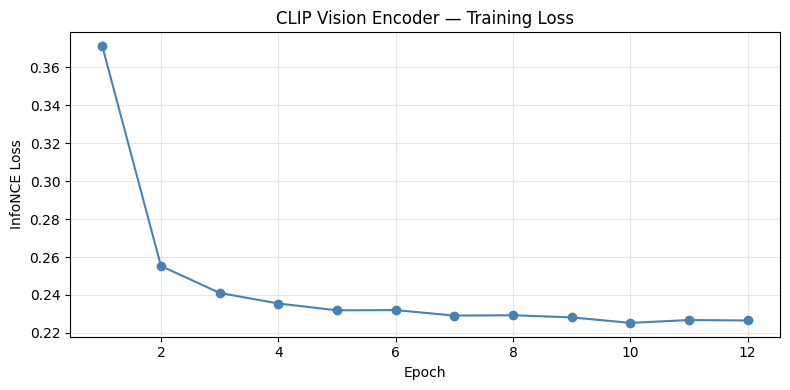

Loss curve saved!


In [10]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(loss_log)+1), loss_log, marker='o', color='steelblue')
plt.xlabel('Epoch')
plt.ylabel('InfoNCE Loss')
plt.title('CLIP Vision Encoder — Training Loss')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/loss_curve.png', dpi=100)
plt.show()
print('Loss curve saved!')

## Step 9 — Re-index Gallery with Adapted CLIP (Config C)

In [11]:
!pip uninstall -y faiss faiss-gpu
!pip install faiss-cpu --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 65.0 MB/s eta 0:00:00


In [12]:
import faiss

# Read gallery split from master table
gallery_df  = master_df[master_df['split'] == 'gallery'].reset_index(drop=True)
gallery_df['img_path'] = gallery_df['crop_path'].apply(translate_path)
gallery_df['on_disk']  = gallery_df['img_path'].apply(
    lambda p: os.path.exists(p) if isinstance(p, str) else False
)
active_gallery = gallery_df[gallery_df['on_disk']].reset_index(drop=True)

with open(os.path.join(CAPTIONS_DIR, 'gallery_captions.json')) as fh:
    gallery_caps = json.load(fh)

# Restore best checkpoint weights
clip_model.load_state_dict(torch.load('/kaggle/working/full_clip_finetuned.pt'))
clip_model.eval()
EMBED_DIM = clip_model.config.projection_dim

GAL_BATCH = 64
gallery_size        = len(active_gallery)
ft_vis_embs  = np.zeros((gallery_size, EMBED_DIM), dtype=np.float32)
ft_lang_embs  = np.zeros((gallery_size, EMBED_DIM), dtype=np.float32)

print(f'Re-encoding {gallery_size:,} gallery images + captions with fine-tuned CLIP...')

for s in tqdm(range(0, gallery_size, GAL_BATCH), desc='Re-encoding'):
    chunk = active_gallery.iloc[s : s + GAL_BATCH]

    imgs, valid_pos = [], []
    for i, (_, row) in enumerate(chunk.iterrows()):
        try:
            imgs.append(Image.open(row['img_path']).convert('RGB'))
            valid_pos.append(i)
        except Exception: pass
    if imgs:
        model_input = clip_processor(images=imgs, return_tensors='pt', padding=True).to(GPU)
        with torch.no_grad():
            vis_features   = clip_model.vision_model(pixel_values=model_input['pixel_values'])
            proj_embs = clip_model.visual_projection(vis_features.pooler_output)
            proj_embs = proj_embs / proj_embs.norm(dim=-1, keepdim=True)
        for li, gi in enumerate(valid_pos):
            ft_vis_embs[s + gi] = proj_embs[li].cpu().numpy()

    caps = [gallery_caps.get(row['image_name'], 'a clothing item') for _, row in chunk.iterrows()]
    text_input = clip_processor(text=caps, return_tensors='pt', padding=True, truncation=True, max_length=77).to(GPU)
    with torch.no_grad():
        text_raw  = clip_model.get_text_features(**text_input)
        text_embs = text_raw.pooler_output if hasattr(text_raw, 'pooler_output') and not isinstance(text_raw, torch.Tensor) else text_raw
        text_embs = text_embs / text_embs.norm(dim=-1, keepdim=True)
    ft_lang_embs[s : s + len(caps)] = text_embs.cpu().numpy()

print('Gallery re-embedding finished!')

# HNSW index configuration for approximate nearest-neighbour retrieval
M         = 32   # edges per graph node — 32 is typical for 512-dimensional embeddings
ef_search = 64   # query beam width during retrieval
ef_constr = 200  # graph build-time beam width

# Produce Config C indexes for both blend coefficients
for beta in [0.7, 0.5]:
    beta_label = f'b{int(beta*10):02d}'
    combined_emb = beta * ft_vis_embs + (1 - beta) * ft_lang_embs
    norms = np.linalg.norm(combined_emb, axis=-1, keepdims=True)
    combined_emb = combined_emb / np.maximum(norms, 1e-8)

    np.save(f'/kaggle/working/gallery_vectors_C_{beta_label}.npy', combined_emb)

    # HNSW uses inner-product; unit-length vectors make it equivalent to cosine similarity
    hnsw_idx = faiss.IndexHNSWFlat(EMBED_DIM, M, faiss.METRIC_INNER_PRODUCT)
    hnsw_idx.hnsw.efSearch       = ef_search
    hnsw_idx.hnsw.efConstruction = ef_constr
    hnsw_idx.add(combined_emb.astype(np.float32))
    faiss.write_index(hnsw_idx, f'/kaggle/working/idx_C_{beta_label}.bin')
    print(f'Config C HNSW index saved: beta={beta}, vectors={hnsw_idx.ntotal:,}  (M={M}, efSearch={ef_search})')


Re-encoding 12,612 gallery images + captions with fine-tuned CLIP...


Re-encoding: 100%|██████████| 198/198 [02:34<00:00,  1.28it/s]


Gallery re-embedding finished!
Config C HNSW index saved: beta=0.7, vectors=12,612  (M=32, efSearch=64)
Config C HNSW index saved: beta=0.5, vectors=12,612  (M=32, efSearch=64)


## Step 10 — Final Summary

In [13]:
print('=' * 60)
print('   CLIP FINE-TUNING + CONFIG C INDEXING COMPLETE')
print('=' * 60)
print(f'  CLIP checkpoint : {CLIP_CKPT}')
print(f'  Epochs trained  : {EPOCHS}')
print(f'  Best loss       : {best_loss:.4f}')
print(f'  Blocks unfrozen : last {THAW_LAYERS}')
print(f'  Text encoder    : FROZEN throughout')
print()
print('  Output files:')
for fn in sorted(os.listdir('/kaggle/working')):
    if fn.endswith(('.pt', '.bin', '.npy', '.png')):
        sz = os.path.getsize(f'/kaggle/working/{fn}') / 1e6
        print(f'    {fn}  ({sz:.1f} MB)')
print()
print('  Next: save output as Kaggle dataset, then run evaluation-c notebook')
print('=' * 60)

   CLIP FINE-TUNING + CONFIG C INDEXING COMPLETE
  CLIP checkpoint : openai/clip-vit-base-patch32
  Epochs trained  : 12
  Best loss       : 0.2253
  Blocks unfrozen : last 4
  Text encoder    : FROZEN throughout

  Output files:
    full_clip_finetuned.pt  (605.3 MB)
    gallery_vectors_C_b05.npy  (25.8 MB)
    gallery_vectors_C_b07.npy  (25.8 MB)
    idx_C_b05.bin  (29.3 MB)
    idx_C_b07.bin  (29.3 MB)
    loss_curve.png  (0.0 MB)
    vision_finetuned.pt  (349.9 MB)

  Next: save output as Kaggle dataset, then run evaluation-c notebook
